In [1]:
from scipy.optimize import least_squares
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from math import e, sin, pi, ceil, log
import numpy as np
import sys
import os

mpl.rc('font',family='Times New Roman', size=20)
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rcParams['mathtext.bf'] = 'Times New Roman:bold'

# Make color map
viridis = mpl.colormaps['viridis']
newcolors = viridis(np.linspace(0, 1, 100))[0:80]
cmap = ListedColormap(newcolors)

sys.setrecursionlimit(5000)

In [2]:
figures_folder = '/Users/veronicabackerperal/Dropbox (Princeton)/Apps/Overleaf/UK Duration/Figures'

In [3]:
def gordon_growth(T, r=0.037, g=0.007, D=1):
    p1tT = 0
    for i in range(1,int(T)+1):
        p1tT += D * ((1+g)/(1+r))**i
    return p1tT

def d_log_price(T, r=0.037, g=0.007, k=90):
    return log(gordon_growth(T+k, r=r, g=g)) - log(gordon_growth(T, r=r, g=g))

def recursive_price(T, time=1, r=0.037, g=0.007, D=1, r_func=lambda x:0.03):
    if T==0:
        return 0
    else:
        dividend = D*(1+g)
        next_price = recursive_price(T-1, r=r, g=g, time=time+1, D=dividend, r_func=r_func)
        return (dividend + next_price)/(1+r_func(time, T=T,r=r))

def objective_function(params, P, T, g, k, func):
    r = params[0]
    estimated_P = func(T=int(T), r=r, g=g, k=k)
    return P - estimated_P    
    
def estimate_ystar(P, T, g=0.007, k=90, func=d_log_price, initial_guess = [0.05]):

    result = least_squares(objective_function, initial_guess, args=(P, T, g, k, func))

    if result.success:
        return result.x[0] - g
    else:
        print("Could not converge!")
        return None
    
def estimated_long_run_rate(func, T=70):
    p0 = recursive_price(T, r_func=func)
    p1 = recursive_price(T+90, r_func=func)
    dp = np.log(p1) - np.log(p0)
    y_t = estimate_ystar(dp, T)
    return y_t

def estimated_spot_rate(func):
    R = 1
    P = recursive_price(1000, r_func=func)
    s_t = R/P
    return s_t

In [4]:
# Generate yield curves
def generate_yield_curve(b):
    def yield_curve(x, r=None, g=0.007, T=None):
        return np.where(x < 50, ((0.037 - b) / 50) * x + b, 0.037)
    return yield_curve

In [5]:
funcs =[generate_yield_curve(intercept) for intercept in np.linspace(0.067,0.007,100)]


In [6]:
ystars = 100*np.array([estimated_long_run_rate(func) for func in funcs])
spot_rates = 100*np.array([estimated_spot_rate(func) for func in funcs])

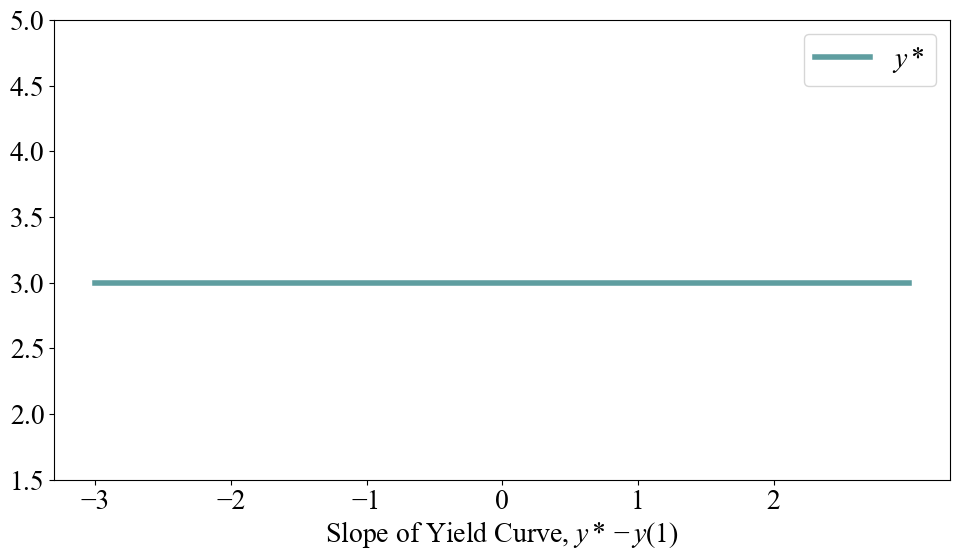

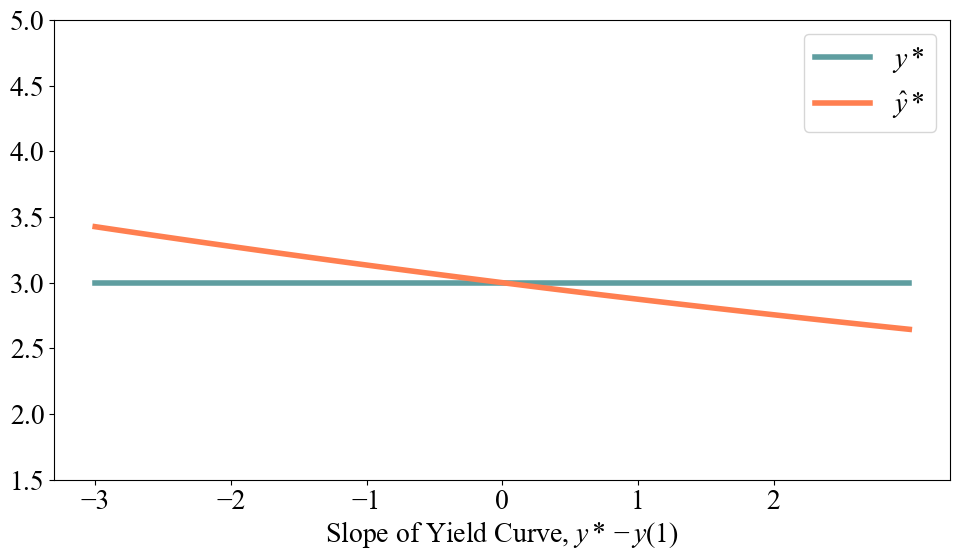

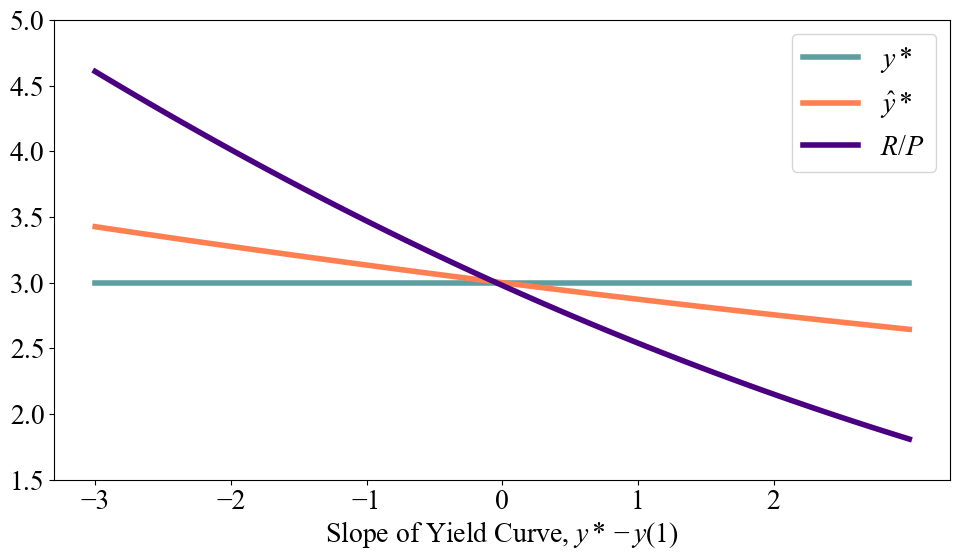

In [25]:
# Data setup
xaxis = np.linspace(-3, 3, 100)

data = [[3]*len(xaxis), ystars, spot_rates]
colors = ['cadetblue', 'coral', 'indigo']
labels = [r'$y*$',r'$\hat{y}*$', r'$R/P$']
for i in range(3):
    plt.figure(figsize=(10, 6))
    for j in range(i+1):
        plt.plot(xaxis, data[j], label=labels[j], color=colors[j], linewidth=4)

    # Adding labels and title
    plt.xlabel(r'Slope of Yield Curve, $y* - y(1)$')
    plt.xticks(list(range(-3,3)))
    plt.yticks(np.linspace(1.5,5,8))

    # Adding legend
    plt.legend()

    # Display the plot
    plt.tight_layout() 
    plt.savefig(os.path.join(figures_folder, 'For_Slides', f'yield_curve_shape_{i+1}.png'))